In [28]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder



In [29]:
df = pd.read_csv("hotels.csv")

In [30]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1258 entries, 0 to 1257
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   title               1258 non-null   object 
 1   price               1258 non-null   float64
 2   adults              1258 non-null   int64  
 3   city                1258 non-null   object 
 4   distance_to_center  1258 non-null   float64
 5   description         1258 non-null   object 
 6   bf_has_included     1258 non-null   bool   
 7   price_category      1258 non-null   object 
dtypes: bool(1), float64(2), int64(1), object(4)
memory usage: 70.2+ KB


In [61]:
df=df.drop_duplicates()

In [62]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1258 entries, 0 to 1257
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   title               1258 non-null   object 
 1   price               1258 non-null   float64
 2   adults              1258 non-null   int64  
 3   city                1258 non-null   object 
 4   distance_to_center  1258 non-null   float64
 5   description         1258 non-null   object 
 6   bf_has_included     1258 non-null   bool   
 7   price_category      1258 non-null   int64  
dtypes: bool(1), float64(2), int64(2), object(3)
memory usage: 70.2+ KB


In [31]:
encoder=LabelEncoder()

In [32]:
encoder

LabelEncoder()

In [33]:
# for col in df.columns:
#     bool_cols = df.select_dtypes(include="bool").columns
#     for col in bool_cols:
#         df[col] = df[col].astype(int)
#     if df[col].dtype == "object":
#         df[col] = encoder.fit_transform(df[col])


In [34]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1258 entries, 0 to 1257
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   title               1258 non-null   object 
 1   price               1258 non-null   float64
 2   adults              1258 non-null   int64  
 3   city                1258 non-null   object 
 4   distance_to_center  1258 non-null   float64
 5   description         1258 non-null   object 
 6   bf_has_included     1258 non-null   bool   
 7   price_category      1258 non-null   object 
dtypes: bool(1), float64(2), int64(1), object(4)
memory usage: 70.2+ KB


In [35]:
df["price_category"] = encoder.fit_transform(df["price_category"])

In [36]:
numeric_features=df.select_dtypes(include=np.number).drop(columns="price_category")

In [37]:
numeric_features.columns.tolist()

['price', 'adults', 'distance_to_center']

# Pearson correlation


In [38]:
pears_corr=df[numeric_features.columns].corrwith(df["price_category"])

In [39]:
pears_corr

price                -0.089618
adults                0.048905
distance_to_center   -0.009945
dtype: float64

# Spearman correlation

In [40]:
spear_corr=df[numeric_features.columns].corrwith(df["price_category"], method="spearman")

In [41]:
spear_corr

price                 0.104969
adults                0.067325
distance_to_center    0.001575
dtype: float64

In [42]:
from scipy.stats import f_oneway

categorical_features=df.select_dtypes(exclude=np.number)

In [43]:
categorical_features

,title,city,description,bf_has_included
0,Bex Sueno Mehmonxonasi,samarkand,Bir kishilik Delyuks xona,True
1,AL MARYAM Mehmonxonasi,samarkand,Bitta katta to'shakli ikki kishilik Delyuks xona,True
2,SAM GREEN HOUSE hostel,samarkand,7 kishilik erkaklar uchun umumiy xona,False
3,Safi Plaza,samarkand,Bitta katta to'shakli ikki kishilik Delyuks xona,True
4,Azam Plaza Hotel,samarkand,Ikkita alohida to'shakli ikki kishilik standar...,True
...,...,...,...,...
1253,Al-Amin Hotel,termez,Bitta katta to'shakli ikki kishilik standart xona,True
1254,Reikartz Termez Palace,termez,Bitta katta to'shakli ikki kishilik standart xona,True
1255,Gold Palace Mehmonxonasi,termez,Ikkita alohida to'shakli ikki kishilik standar...,True
1256,Marshal Hosteli,termez,"To'rt kishilik xona ""Komfort""",True


# Anova 

In [44]:
anova_results={}

for col in categorical_features:
    groups = [df[df[col] == val]['price_category'] for val in df[col].unique()]
    if len(groups) > 1:
        f_stat, p_val = f_oneway(*groups)
        anova_results[col] = {'F-statistic': f_stat, 'p-value': p_val}

anova_df = pd.DataFrame(anova_results).T.sort_values('p-value')
print("ANOVA Results for Categorical Features vs xG:\n")
print(anova_df)

ANOVA Results for Categorical Features vs xG:

                 F-statistic       p-value
description         1.922712  1.661572e-07
bf_has_included    10.315945  1.352309e-03
city                1.272665  2.345780e-01
title               0.767921  9.967799e-01


# Correlation with other festures


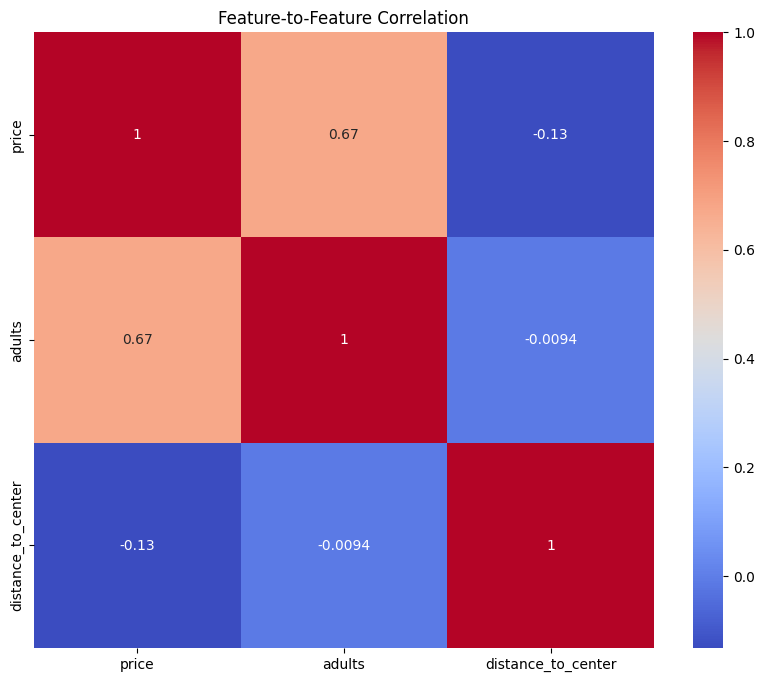

Highly correlated features to drop: ['adults']


In [46]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))
sns.heatmap(df[numeric_features.columns].corr(), annot=True, cmap='coolwarm')
plt.title("Feature-to-Feature Correlation")
plt.show()

# Example: drop features with correlation > 0.9
corr_matrix = df[numeric_features.columns].corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
to_drop = [column for column in upper.columns if any(upper[column] > 0.6)]
print("Highly correlated features to drop:", to_drop)


# Feature Importance

In [66]:
#Linear
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

X = numeric_features
y = df["price_category"]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

lr = LogisticRegression()
lr.fit(X_scaled, y)

coef_df = pd.DataFrame(
    lr.coef_,
    columns=X.columns,
    index=lr.classes_
)

print(coef_df)



       price    adults  distance_to_center
0 -11.670535 -1.058802            0.170289
1  10.691262  0.641634           -0.243762
2   3.808129  0.542776            0.043479
3  -2.828856 -0.125609            0.029994


In [67]:
# Tree
from sklearn.ensemble import RandomForestClassifier
import pandas as pd

rf = RandomForestClassifier(random_state=42)
rf.fit(X, y)

# Feature importance
feat_importance = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)
print("Random Forest Feature Importance:\n", feat_importance)


Random Forest Feature Importance:
 price                 0.781563
adults                0.173806
distance_to_center    0.044631
dtype: float64


# Performance Impact

In [68]:
y.unique()

array([0, 3, 2, 1])

In [69]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Train full model
rf.fit(X_train, y_train)
y_pred_full = rf.predict(X_test)
full_acc = accuracy_score(y_test, y_pred_full)

# Drop one feature example
X_train_reduced = X_train.drop(columns=['price'])
X_test_reduced = X_test.drop(columns=['price'])
rf.fit(X_train_reduced, y_train)
y_pred_reduced = rf.predict(X_test_reduced)
reduced_acc= accuracy_score(y_test, y_pred_reduced)

print(f"Full model Accuracy: {full_acc:.3f}")
print(f"Reduced model Accuracy: {reduced_acc:.3f}")


Full model Accuracy: 1.000
Reduced model Accuracy: 0.550
